# Imports

In [27]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from src.data.sampling import get_training_data_spectra
import numpy as np
import zarr

from src.data.augmentation import (
    add_whitenoise,
    add_polynomial,
    add_co2,
    add_scattering,
    add_cylindrical_scattering,
    get_imagpart,
    get_nkk,
    augment_cosmic_rays,
    augment_shot_noise,
    FluorescenceBackgroundAugmentor,
    AugmentationPipeline,
    _apply_paraffin,
    _apply_homogenizer_degradation,
    _apply_temperature_perturbation,
    _apply_preservative_effect,
    _apply_dilution,
    _apply_wavenumber_shift,
)

# from master: works for previous zarr-stores to be harmonized
def get_training_data(
    split: list | None = None,
    zarr_path: str = "/mnt/ssd3/eirik/ProcessedData/microplastics_library.zarr",
    spectra_per_class: int = 8,
    bkg_per_class: int = 4,
    patch_size: int = 128,
    background_max: float = 0.1,
    sample_min: float = 0.5,
    max_class_attempts: int = 1000,
    include_bkg_pixels: bool = True,
) -> tuple[np.ndarray, np.ndarray, np.ndarray, dict[str, int]]:

    root = zarr.open(zarr_path, mode="r")
    images_group = root["images"]
    wn = np.asarray(root.attrs["wavenumbers"], dtype=np.float32)
    if split is None:
        split = [
            {"name": name, "label": images_group[name].attrs.get("label", name)}
            for name in images_group.keys()
        ]
    unique_labels = sorted(list(set(item["label"] for item in split)))
    rng = np.random.default_rng()
    spectra_per_patch = max(1, spectra_per_class // len(unique_labels))
    all_spectra, all_labels = [], []
    label_encoding = {"bkg": 0} if include_bkg_pixels else {}
    for i, label in enumerate(unique_labels):
        class_idx = i + 1 if include_bkg_pixels else i
        label_encoding[label] = class_idx
        names = [item["name"] for item in split if item["label"] == label]
        attempts = 0
        p_sample, p_bkg = [], []
        while len(p_sample) < spectra_per_class or (include_bkg_pixels and len(p_bkg) < bkg_per_class):
            attempts += 1
            if attempts > max_class_attempts:
                bkg_status = f", {len(p_bkg)}/{bkg_per_class} background" if include_bkg_pixels else ""
                raise RuntimeError(
                    f"\n[Data Sampling Error] Class '{label}' failed to meet quotas after {max_class_attempts} attempts.\n"
                    f"Found: {len(p_sample)}/{spectra_per_class} plastic{bkg_status}.\n"
                    f"Check if background_max ({background_max}) or sample_min ({sample_min}) are too restrictive."
                )
            name = names[rng.integers(len(names))]
            z_arr = images_group[name]["data"]
            H, W, L = z_arr.shape
            y0 = rng.integers(0, max(1, H - patch_size))
            x0 = rng.integers(0, max(1, W - patch_size))
            patch = z_arr[y0 : y0 + patch_size, x0 : x0 + patch_size]
            spectra = patch.reshape(-1, L)
            means = spectra.mean(axis=1)
            if len(p_sample) < spectra_per_class:
                spec_mask = means > sample_min
                if spec_mask.any():
                    valid = spectra[spec_mask]
                    k = min(spectra_per_patch, len(valid), spectra_per_class - len(p_sample))
                    p_sample.extend(rng.choice(valid, size=k, replace=False))
            if include_bkg_pixels and len(p_bkg) < bkg_per_class:
                bkg_mask = means < background_max
                if bkg_mask.any():
                    valid = spectra[bkg_mask]
                    k = min(spectra_per_patch, len(valid), bkg_per_class - len(p_bkg))
                    p_bkg.extend(rng.choice(valid, size=k, replace=False))
        all_spectra.append(np.stack(p_sample))
        all_labels.append(np.full(len(p_sample), class_idx))
        if include_bkg_pixels:
            all_spectra.append(np.stack(p_bkg))
            all_labels.append(np.zeros(len(p_bkg)))

    return np.hstack(all_labels), np.vstack(all_spectra), wn, label_encoding

# IR

## Pure absorption spectrum

In [97]:
labels, spectra, wns, label_encoding = get_training_data_spectra(zarr_path="/mnt/ssd3/eirik/ProcessedData/pcuk.zarr",
                                                                 spectra_per_class=256,
                                                                 classes=["Normal epithelium", "Normal stroma",
                                                                         "Cancerous epithelium", "Cancer-associated stroma"])


Class                                          Available  Sampled
-----------------------------------------------------------------
  Normal epithelium                              183,651      256
  Normal stroma                                  154,041      256
  Cancerous epithelium                           246,092      256
  Cancer-associated stroma                        76,174      256

  Balanced at 256 px/class  ->  1,024 total



(-0.1, 1.0)

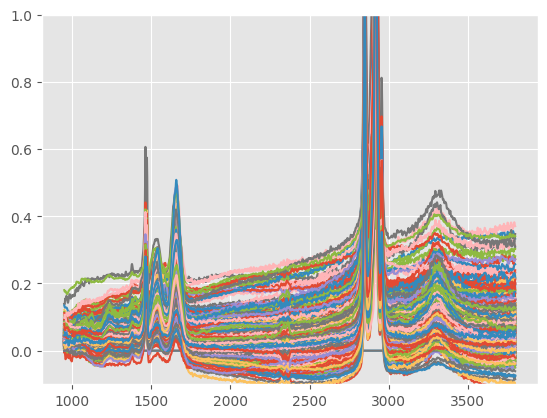

In [98]:
wns_pcuk, spectra_pcuk = wns, spectra
plt.plot(wns_pcuk, spectra_pcuk.T);
plt.ylim(-0.1, 1)

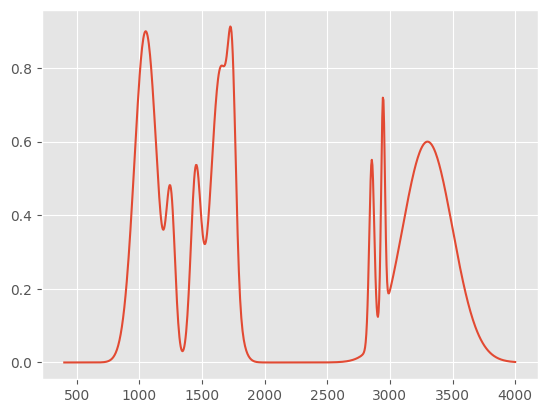

In [93]:
np.random.seed(42)
wns = np.linspace(400, 4000, 737)

def make_base_spectrum(wn):
    s = np.zeros_like(wn)
    peaks = [(1650, 80, 0.8), (2945, 15, .6), (1450, 40, 0.5),
             (3300, 200, 0.6), (1250, 35, 0.4), (1050, 90, 0.9),
             (2855, 20, 0.5), (1740, 30, 0.45)]
    for center, width, height in peaks:
        s += height * np.exp(-((wn - center) ** 2) / (2 * width ** 2))
    return s

base = make_base_spectrum(wns)
plt.plot(wns, base)

## Gaussian noise

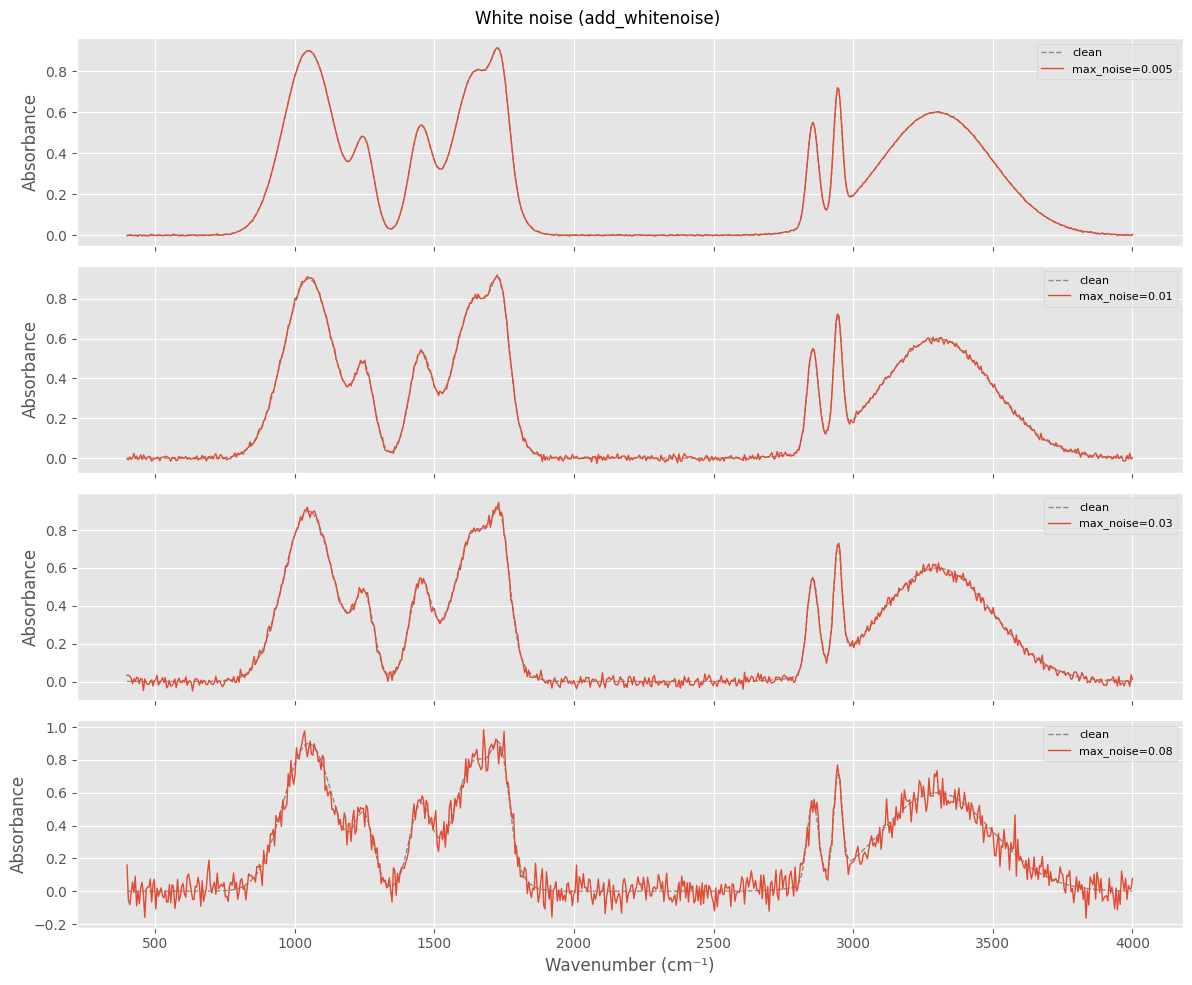

In [19]:
noise_levels = [0.005, 0.01, 0.03, 0.08]
fig, axes = plt.subplots(len(noise_levels), 1, figsize=(12, 10), sharex=True)
for ax, max_noise in zip(axes, noise_levels):
    batch = base[None].copy()
    aug = add_whitenoise(batch.copy(), max_noise=max_noise)
    ax.plot(wavenumbers, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wavenumbers, aug[0], lw=1, label=f'max_noise={max_noise}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('White noise (add_whitenoise)')
plt.tight_layout()
plt.show()

## Polynomial baselines

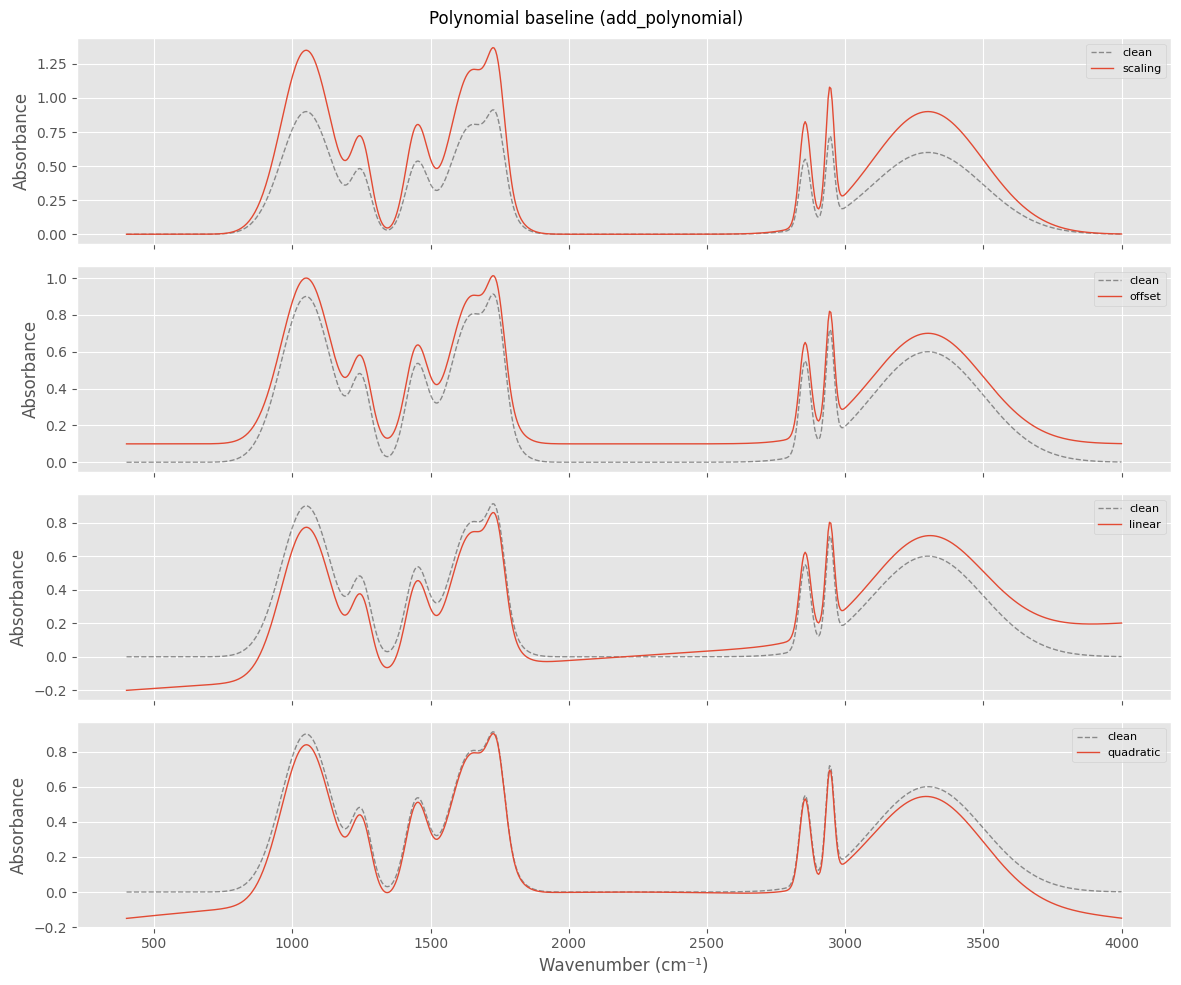

In [29]:
configs = [
    ([0., 1.5, 0.0, 0.0],   'scaling'),
    ([0.1, 1.0, 0.0, 0.0],   'offset'),
    ([0.0,  1.0, 0.2, 0.0],   'linear'),
    ([0.0,  1., 0., -0.15],  'quadratic'),
]
fig, axes = plt.subplots(len(configs), 1, figsize=(12, 10), sharex=True)
for ax, (p, label) in zip(axes, configs):
    batch = base[None].copy()
    params = [np.array([v]) for v in p]
    aug = add_polynomial(batch.copy(), wavenumbers, params)
    ax.plot(wavenumbers, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wavenumbers, aug[0], lw=1, label=label)
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Polynomial baseline (add_polynomial)')
plt.tight_layout()
plt.show()

## Wavenumber shift

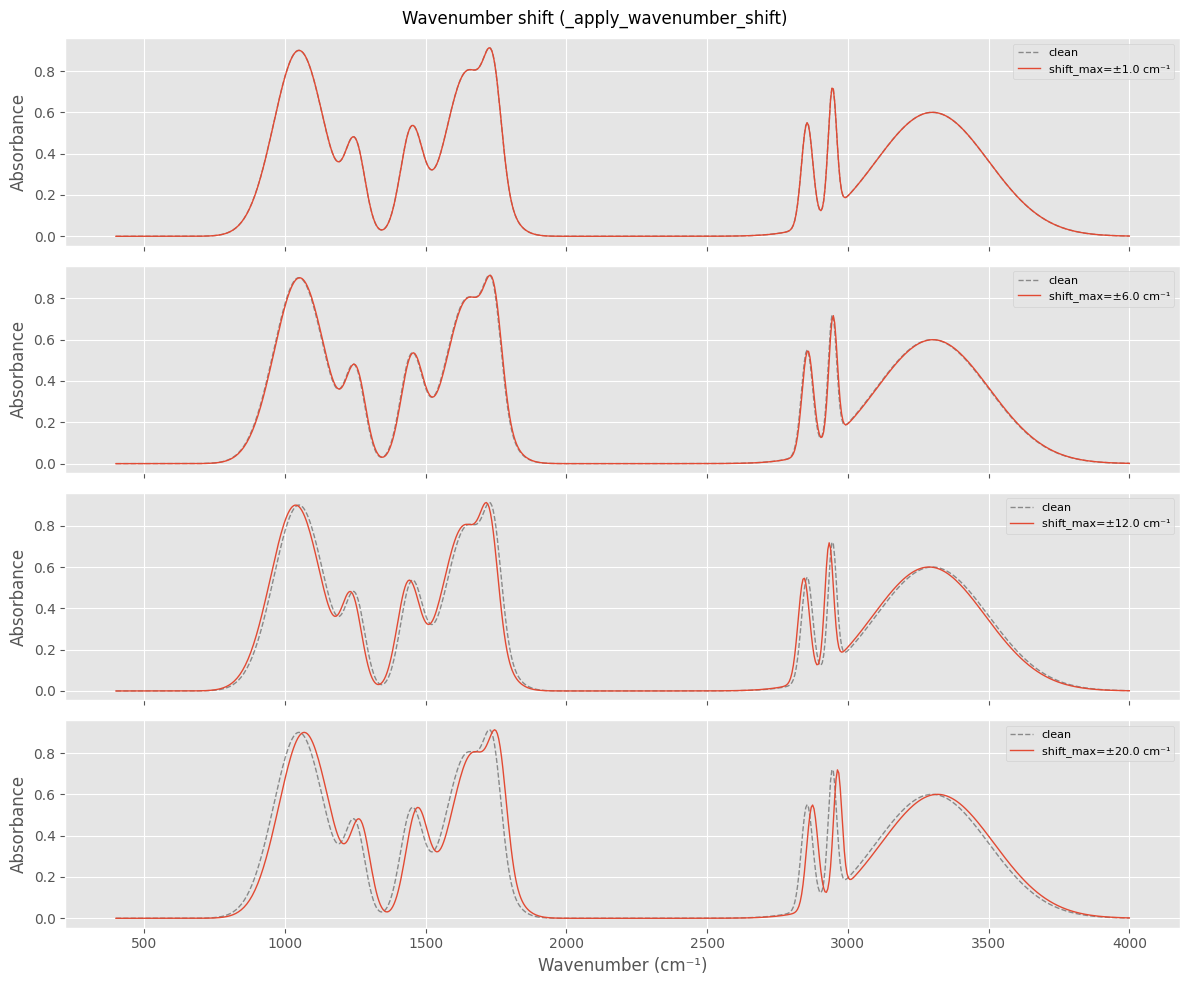

In [96]:
shift_maxes = [1.0, 6.0, 12.0, 20.0]
fig, axes = plt.subplots(len(shift_maxes), 1, figsize=(12, 10), sharex=True)
for ax, shift_max in zip(axes, shift_maxes):
    batch = base[None].copy()
    mask = np.array([True])
    cfg = {'shift_max': shift_max, 'per_batch': False}
    aug = _apply_wavenumber_shift(batch.copy(), mask, wns, cfg)
    ax.plot(wns, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wns, aug[0], lw=1, label=f'shift_max=±{shift_max} cm⁻¹')
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Wavenumber shift (_apply_wavenumber_shift)')
plt.tight_layout()
plt.show()

## CO2 augmentation

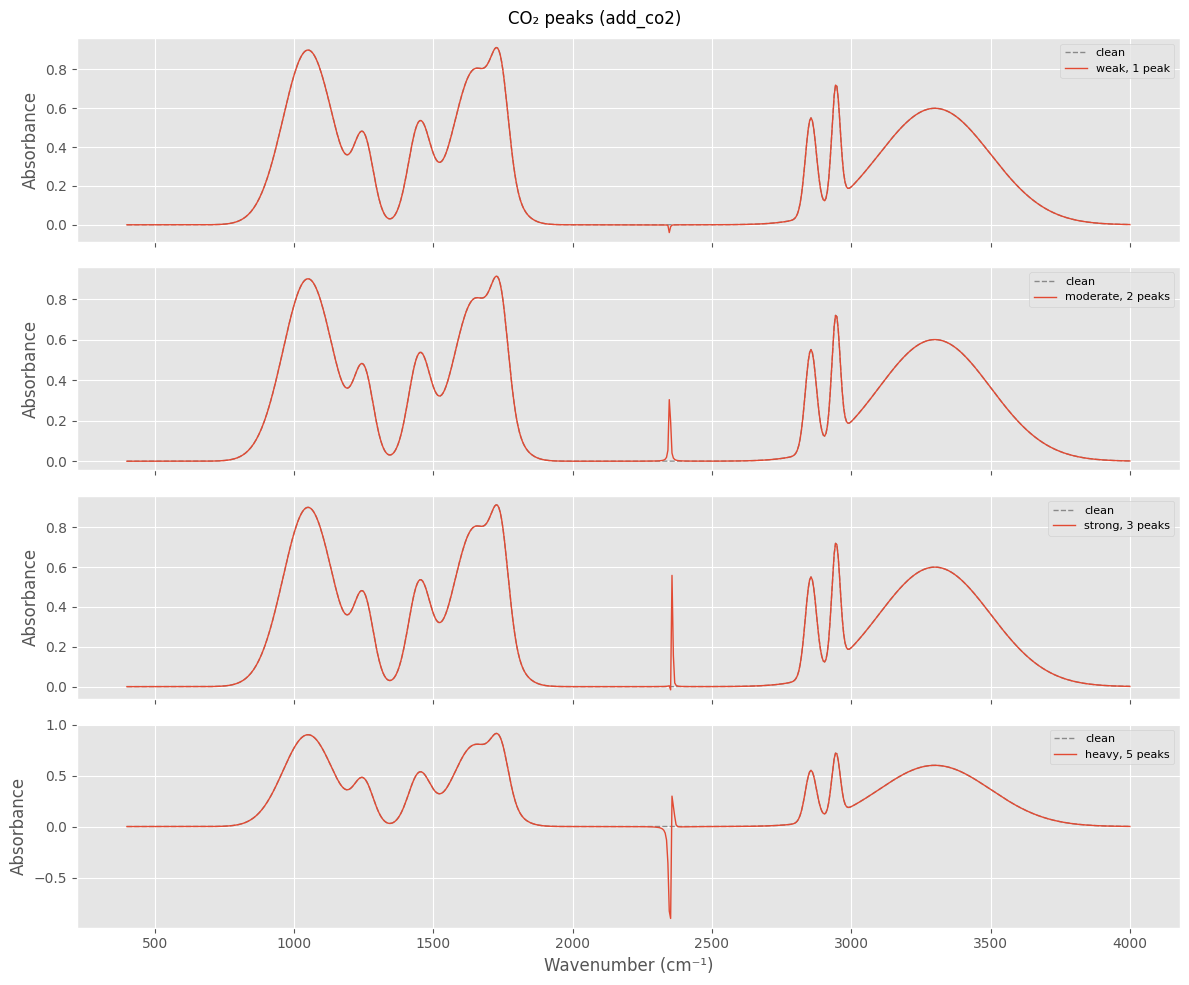

In [42]:
np.random.seed(420)
configs = [
    [2349, 2349, 0.5, 0., 0.3, 3.0, 0.5, 1],
    [2349, 2349, 1.0, 0., 0.5, 5.0, 1.0, 2],
    [2349, 2360, 2.0, 0., 0.5, 4.0, 1.5, 3],
    [2340, 2360, 3.0, 0., 0.8, 6.0, 2.0, 5],
]
labels = ['weak, 1 peak', 'moderate, 2 peaks', 'strong, 3 peaks', 'heavy, 5 peaks']
fig, axes = plt.subplots(len(configs), 1, figsize=(12, 10), sharex=True)
for ax, (co2_params, label) in zip(axes, zip(configs, labels)):
    batch = base[None].copy()
    aug = add_co2(batch.copy(), wavenumbers, co2_params)
    ax.plot(wavenumbers, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wavenumbers, aug[0], lw=1, label=label)
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('CO₂ peaks (add_co2)')
plt.tight_layout()
plt.show()

## Homogenizer degradation

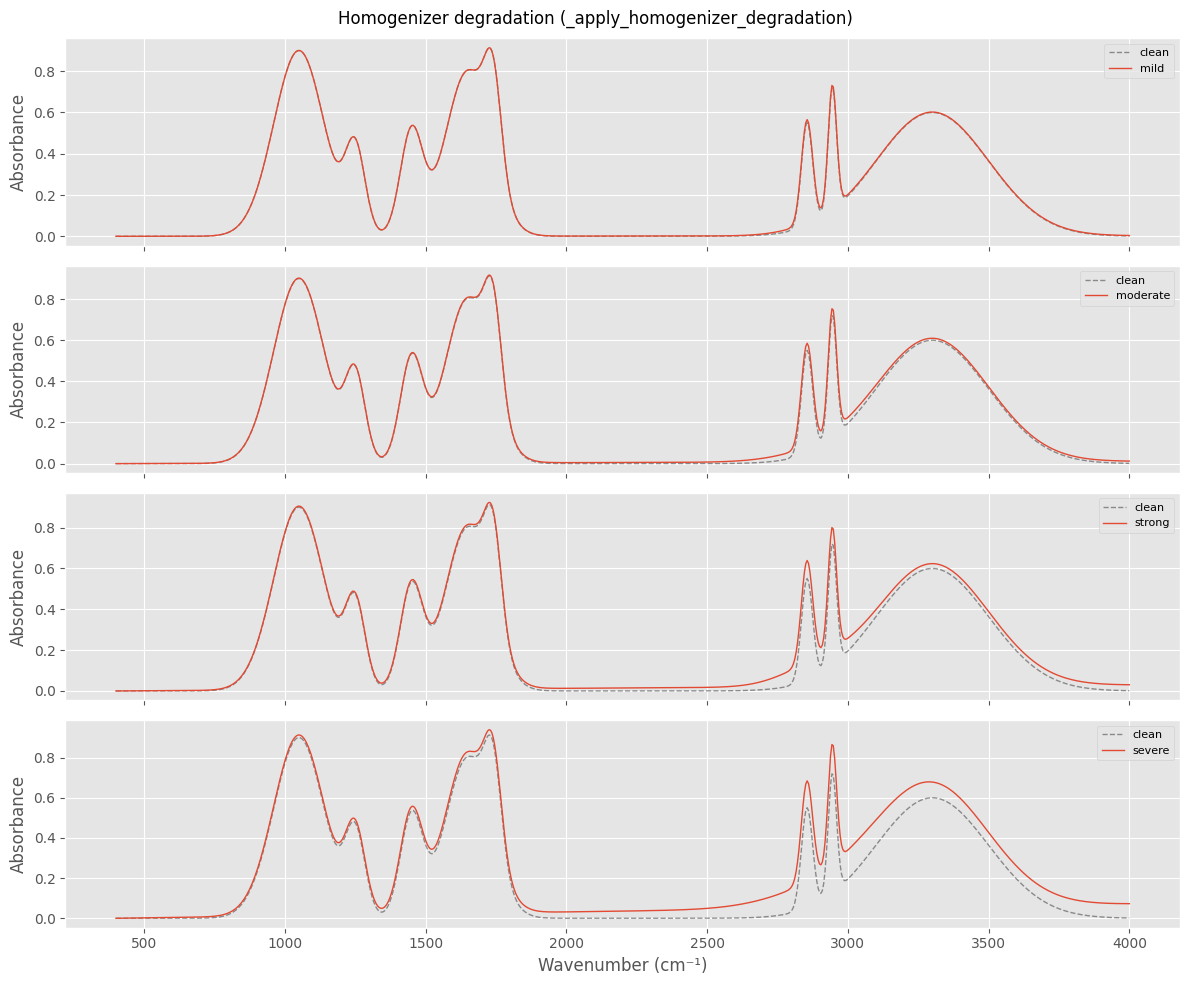

In [71]:
configs = [
    {'amplitude_min': 0.01, 'amplitude_max': 0.02, 'bump_center': 2900.0,
     'bump_width': 100.0, 'slope_strength': 0.2, 'bump_strength': 1.0},
    {'amplitude_min': 0.03, 'amplitude_max': 0.06, 'bump_center': 2900.0,
     'bump_width': 150.0, 'slope_strength': 0.4, 'bump_strength': 1.0},
    {'amplitude_min': 0.08, 'amplitude_max': 0.12, 'bump_center': 2850.0,
     'bump_width': 120.0, 'slope_strength': 0.5, 'bump_strength': 1.2},
    {'amplitude_min': 0.15, 'amplitude_max': 0.20, 'bump_center': 2950.0,
     'bump_width': 200.0, 'slope_strength': 0.6, 'bump_strength': 0.8},
]
labels = ['mild', 'moderate', 'strong', 'severe']
fig, axes = plt.subplots(len(configs), 1, figsize=(12, 10), sharex=True)
for ax, (cfg, label) in zip(axes, zip(configs, labels)):
    batch = base[None].copy()
    mask = np.array([True])
    cfg['relative_amplitude'] = True
    aug = _apply_homogenizer_degradation(batch.copy(), mask, wns, cfg)
    ax.plot(wns, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wns, aug[0], lw=1, label=label)
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Homogenizer degradation (_apply_homogenizer_degradation)')
plt.tight_layout()
plt.show()

## Dilution towards water

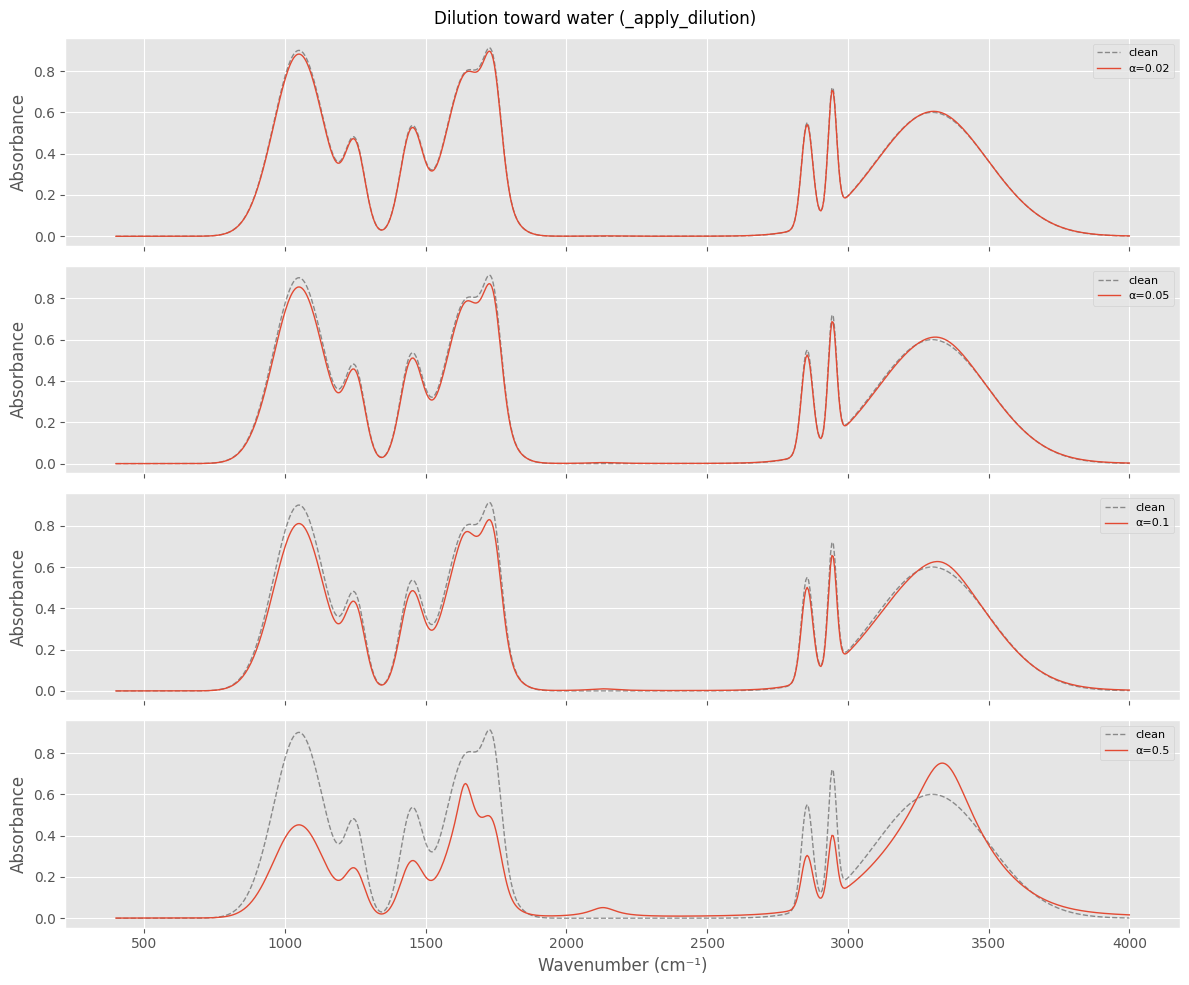

In [70]:
dilution_levels = [0.02, 0.05, 0.10, .50]
fig, axes = plt.subplots(len(dilution_levels), 1, figsize=(12, 10), sharex=True)
for ax, dil in zip(axes, dilution_levels):
    batch = base[None].copy()
    mask = np.array([True])
    cfg = {'dilution_min': dil, 'dilution_max': dil, 'scale_reference': True}
    aug = _apply_dilution(batch.copy(), mask, wns, cfg)
    ax.plot(wns, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wns, aug[0], lw=1, label=f'α={dil}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Dilution toward water (_apply_dilution)')
plt.tight_layout()
plt.show()

## Paraffin contamination

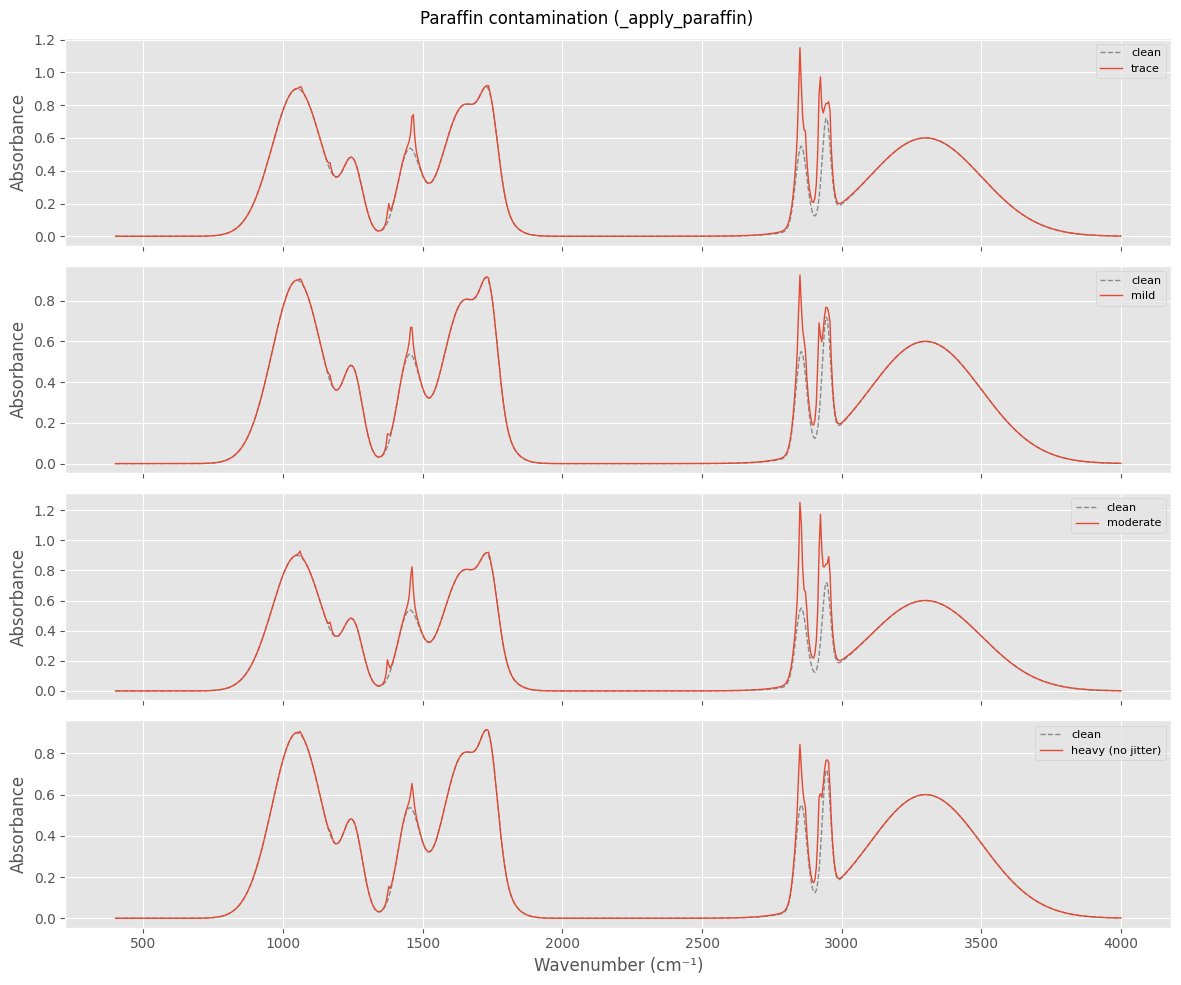

In [82]:
configs = [
    {'ratio': 1.0, 'amplitude_min': 0.005, 'amplitude_max': 1.01,  'randomise_bands': True},
    {'ratio': 1.0, 'amplitude_min': 0.02,  'amplitude_max': 1.04,  'randomise_bands': True},
    {'ratio': 1.0, 'amplitude_min': 0.06,  'amplitude_max': 1.10,  'randomise_bands': True},
    {'ratio': 1.0, 'amplitude_min': 0.15,  'amplitude_max': 1.25,  'randomise_bands': False},
]
labels = ['trace', 'mild', 'moderate', 'heavy (no jitter)']
fig, axes = plt.subplots(len(configs), 1, figsize=(12, 10), sharex=True)
for ax, (cfg, label) in zip(axes, zip(configs, labels)):
    batch = base[None].copy()
    mask = np.array([True])
    aug = _apply_paraffin(batch.copy(), mask, wns, cfg)
    ax.plot(wns, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wns, aug[0], lw=1, label=label)
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Paraffin contamination (_apply_paraffin)')
plt.tight_layout()
plt.show()

## Temperature effects

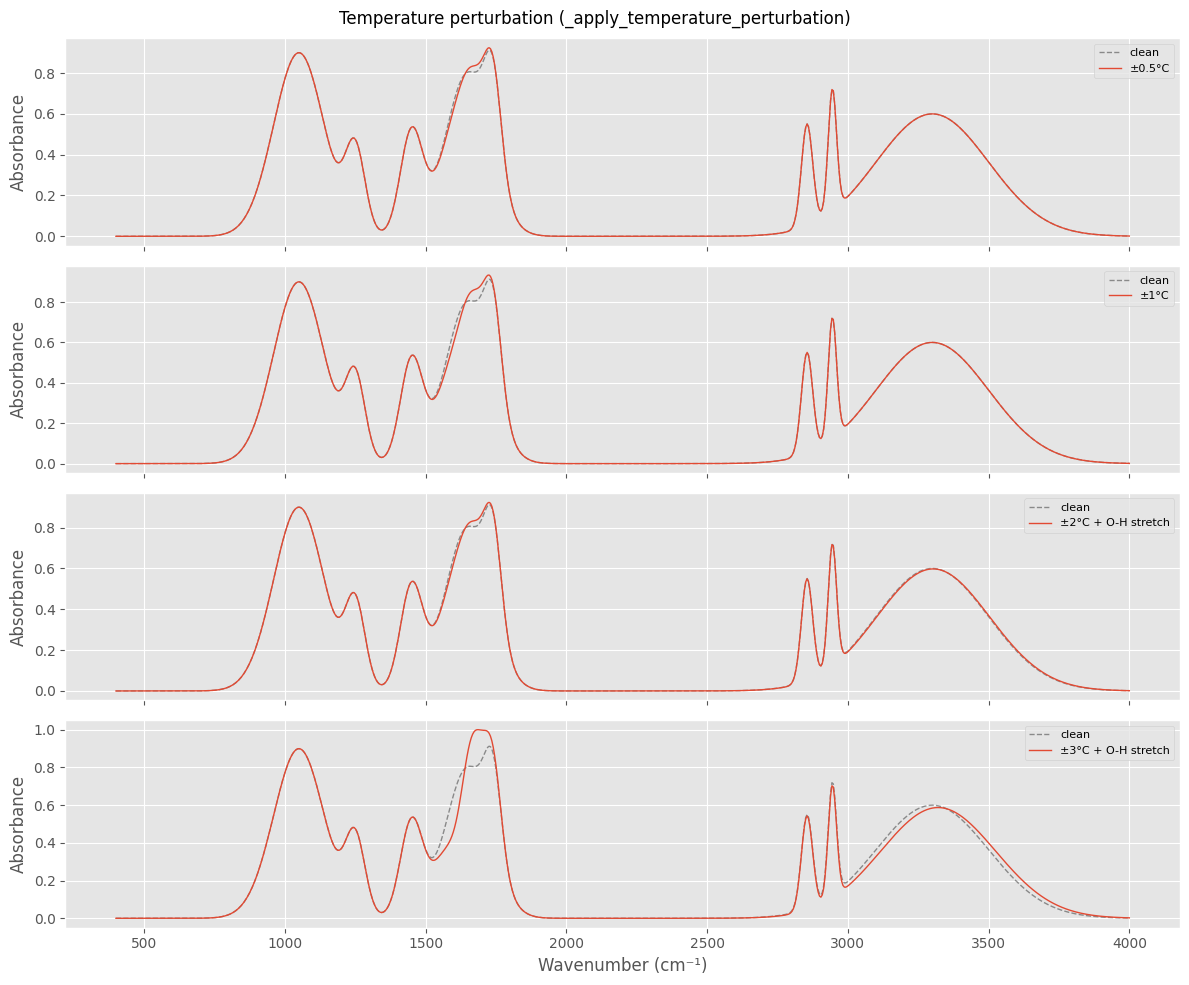

In [80]:
configs = [
    {'temp_delta_max': 0.5,  'shift_per_degree': 5.3, 'band_center': 1640.0, 'band_width': 40.0},
    {'temp_delta_max': 1.0,  'shift_per_degree': 5.3, 'band_center': 1640.0, 'band_width': 40.0},
    {'temp_delta_max': 2.0,  'shift_per_degree': 5.5, 'band_center': 1640.0, 'band_width': 40.0, 'extra_bands': [[3350.0, 200.0]]},
    {'temp_delta_max': 3.0,  'shift_per_degree': 5.5, 'band_center': 1640.0, 'band_width': 40.0, 'extra_bands': [[3350.0, 200.0]]},
]

labels = ['±0.5°C', '±1°C', '±2°C + O-H stretch', '±3°C + O-H stretch']
fig, axes = plt.subplots(len(configs), 1, figsize=(12, 10), sharex=True)
for ax, (cfg, label) in zip(axes, zip(configs, labels)):
    batch = base[None].copy()
    mask = np.array([True])
    aug = _apply_temperature_perturbation(batch.copy(), mask, wns, cfg)
    ax.plot(wns, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wns, aug[0], lw=1, label=label)
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Temperature perturbation (_apply_temperature_perturbation)')
plt.tight_layout()
plt.show()

# Raman

## Pure Raman spectra

In [31]:
(labels, spectra, wns, label_encoding) = get_training_data(zarr_path = '/mnt/ssd3/eirik/ProcessedData/mlrod.zarr', 
                                                      spectra_per_class=10,
                                                      background_max=0.,
                                                      sample_min = 0.,
                                                      include_bkg_pixels=False)

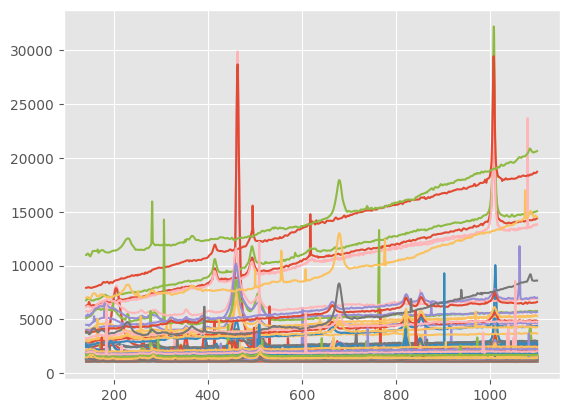

In [35]:
plt.plot(wns, spectra.T);

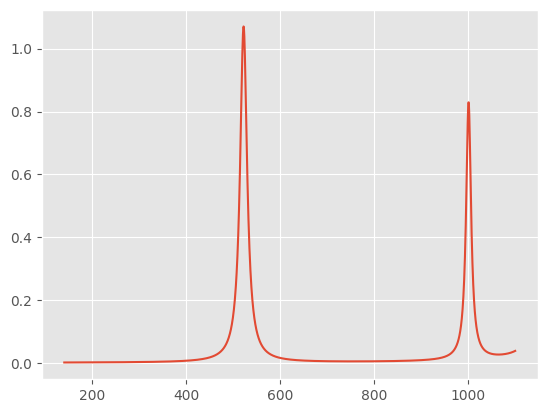

In [32]:
def make_raman_spectrum(wn):    
    s = np.zeros_like(wn)
    peaks = [
        (520,   8,  0.9),   # Si reference (sharp)
        (1002,  6,  0.7),   # phenylalanine ring breathing
        (1156,  12, 0.4),   # C-C stretch carotenoid
        (1210,  15, 0.3),   # phenylalanine / tryptophan
        (1265,  18, 0.35),  # amide III
        (1302,  14, 0.45),  # CH2 twist lipids
        (1445,  16, 0.6),   # CH2 deformation lipids/proteins
        (1519,  10, 0.5),   # carotenoid C=C stretch
        (1580,  20, 0.4),   # G-band / amide II
        (1614,  12, 0.35),  # tryptophan / tyrosine
        (1655,  22, 0.65),  # amide I C=O stretch
        (2727,  18, 0.15),  # CH overtone (weak)
        (2850,  20, 0.55),  # CH2 sym stretch lipids
        (2920,  22, 0.80),  # CH2 asym stretch lipids/proteins
        (2960,  18, 0.45),  # CH3 stretch
        (3060,  15, 0.20),  # aromatic C-H stretch
    ]
    
    for center, width, height in peaks:
        c = center + np.random.normal(0, 1.5)
        w = width  * np.random.uniform(0.85, 1.15)
        h = height * np.random.uniform(0.80, 1.20)
        w2   = w ** 2
        diff = (wn - c) ** 2
        s += h * (w2 / (w2 + diff))
    return s

# wns = np.linspace(400, 3200, 737)
base = make_raman_spectrum(wns)
plt.plot(wns, base)

## Cosmic ray

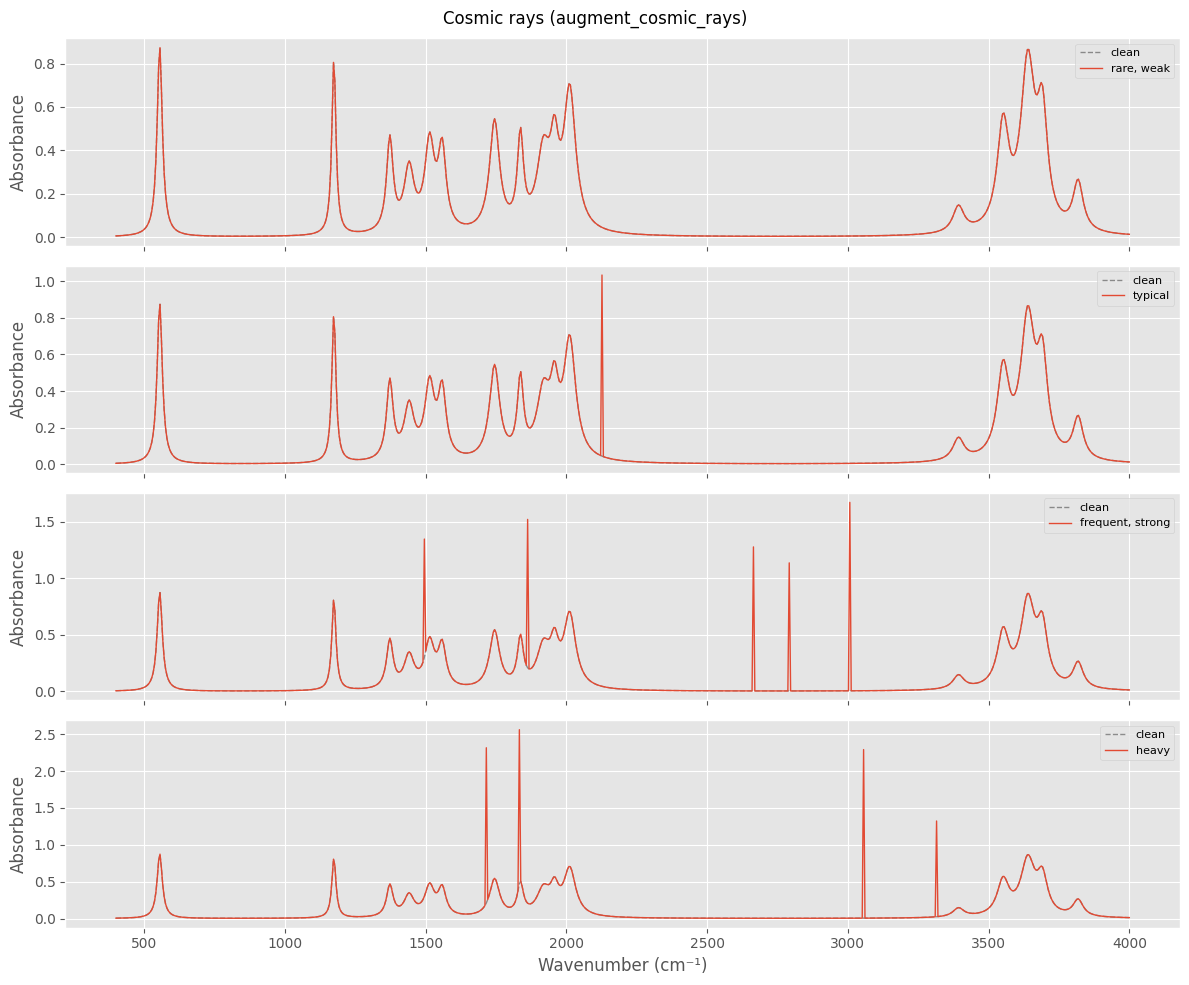

In [55]:
configs = [
    (0.001, (2.0, 5.0),  1),
    (0.002, (5.0, 10.0), 2),
    (0.005, (8.0, 15.0), 2),
    (0.010, (10.0, 20.0), 3),
]
labels = ['rare, weak', 'typical', 'frequent, strong', 'heavy']
fig, axes = plt.subplots(len(configs), 1, figsize=(12, 10), sharex=True)
for ax, ((rate, amp_range, max_w), label) in zip(axes, zip(configs, labels)):
    x = torch.from_numpy(base[None]).float()
    aug = augment_cosmic_rays(x, spike_rate=rate, amplitude_range=amp_range, max_width=max_w)
    ax.plot(wavenumbers, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wavenumbers, aug[0].numpy(), lw=1, label=label)
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Cosmic rays (augment_cosmic_rays)')
plt.tight_layout()
plt.show()

## Flourescence background

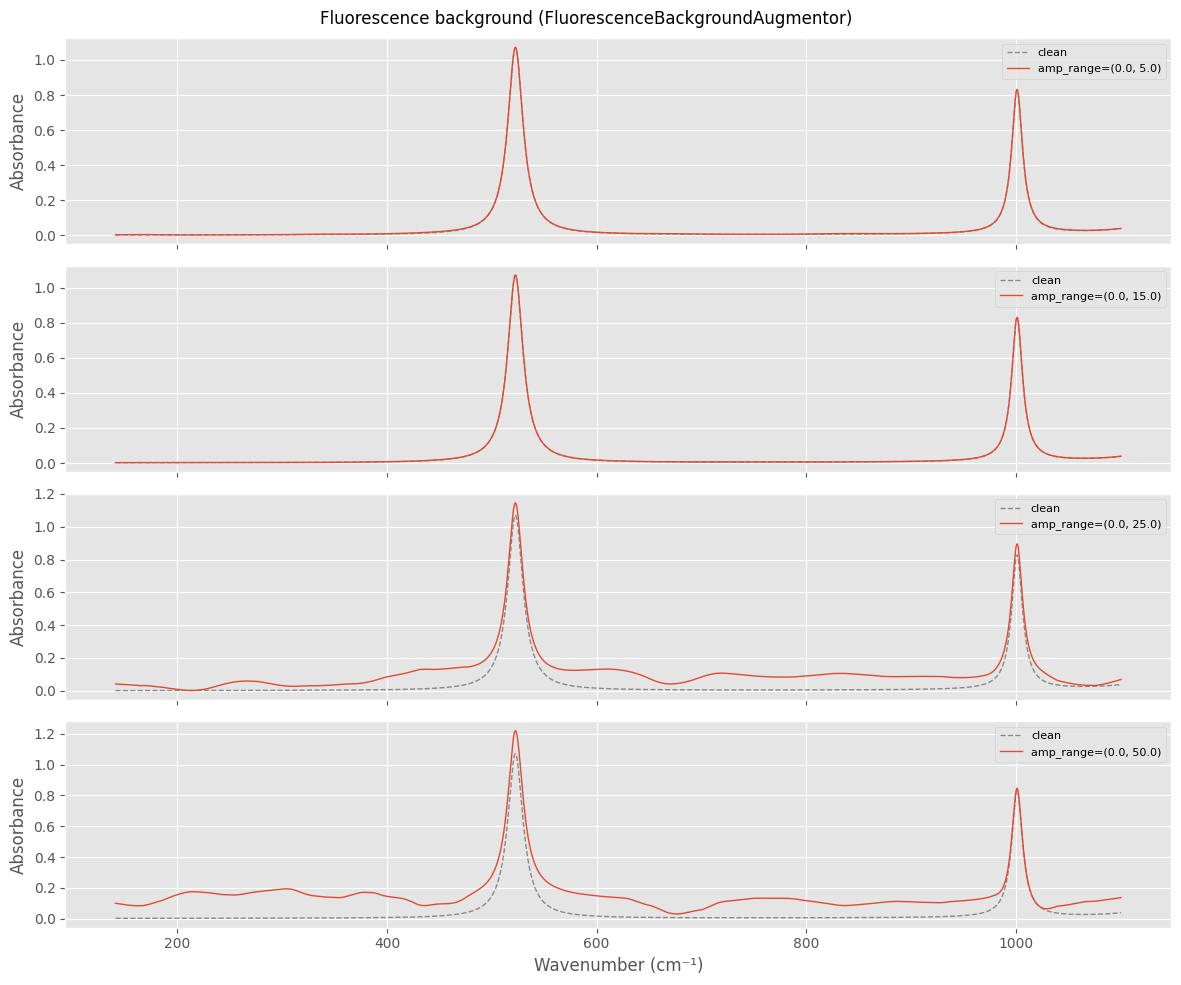

In [61]:
# *fluor_aug??

wn_tensor = torch.from_numpy(wns).float()
fluor_aug = FluorescenceBackgroundAugmentor(wn_tensor, n_components=10, poly_degree=3)

from scipy.signal import savgol_filter

def extract_baselines(spectra_np, window=251, poly=3):
    smoothed = savgol_filter(spectra_np, window_length=window, polyorder=poly, axis=1)
    return np.minimum(spectra_np, smoothed)

baselines = extract_baselines(spectra)
fluor_aug.fit(torch.from_numpy(baselines).float())


amp_ranges = [(0., 5.0), (0.0, 15.), (0.0, 25.), (0.0, 50.)]
fig, axes = plt.subplots(len(amp_ranges), 1, figsize=(12, 10), sharex=True)
for ax, amp_range in zip(axes, amp_ranges):
    x = torch.from_numpy(base[None]).float()
    aug = fluor_aug(x, amplitude_range=amp_range)
    ax.plot(wns, base, 'k--', alpha=0.4, lw=1, label='clean')
    ax.plot(wns, aug[0].numpy(), lw=1, label=f'amp_range={amp_range}')
    ax.legend(fontsize=8)
    ax.set_ylabel('Absorbance')
axes[-1].set_xlabel('Wavenumber (cm⁻¹)')
plt.suptitle('Fluorescence background (FluorescenceBackgroundAugmentor)')
plt.tight_layout()
plt.show()